# MP2 Parts 2–3 — commit trends, gaps and gap interpretation (aamphone)
Input: `aamphone_project_summary.csv` from Part 1. Outputs:
- `aamphone_commits_timeseries_<WOCProjectID>.csv` and `aamphone_timeseries_<WOCProjectID>.png` (10 each)
- `aamphone_project_gap_commits.csv`
- `aamphone_project_stats.csv`

In [1]:
import re
import subprocess
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

NETID = 'aamphone'
SUMMARY = NETID + '_project_summary.csv'
STATUS_AS_OF = pd.Timestamp('2025-09-30')   # README: Active if a GitHub commit in the 6 months before this date
STATUS_CUTOFF = pd.Timestamp('2025-04-01')

# GitHub data collected from each repository page on 2026-10-07 (see aamphone.ipynb)
github = pd.DataFrame([
    # project, GitHub repo, stars, forks, last commit date (default branch)
    ('arviz-devs_arviz',                  'arviz-devs/arviz',                  1800, 501, '2026-09-09'),
    ('clindatsci_dicomweb-python-client', 'clindatsci/dicomweb-python-client', 129,  42,  '2026-08-17'),
    ('peal_vole',                         'peal/vole',                         8,    2,   '2026-07-01'),
    ('nbara_python-meegkit',              'nbara/python-meegkit',              227,  57,  '2026-08-21'),
    ('flyaflya_causact',                  'flyaflya/causact',                  47,   12,  '2025-09-12'),
    ('geolytix_xyz',                      'GEOLYTIX/xyz',                      132,  44,  '2026-10-02'),
    ('genouest_biomaj-download',          'genouest/biomaj-download',          1,    7,   '2025-05-20'),
    ('pressio_pressio',                   'Pressio/pressio',                   50,   7,   '2025-09-10'),
    ('kkondo1981_aglm',                   'kkondo1981/aglm',                   17,   5,   '2025-05-12'),
    ('winvector_vtreat',                  'WinVector/vtreat',                  284,  45,  '2025-01-09'),
], columns=['project', 'repo', 'nstars', 'nforks', 'lastGHCommitDate']).set_index('project')
projects = list(github.index)

## Load the Part 1 commit table

In [2]:
def load_summary(path):
    """Reads the summary whether it is ';' or ',' separated and with or without a header row."""
    for sep in (';', ','):
        try:
            d = pd.read_csv(path, sep=sep, header=None, dtype=str, keep_default_na=False)
        except pd.errors.ParserError:
            continue
        if d.shape[1] == 5:
            break
    else:
        raise ValueError('could not parse ' + path)
    d.columns = ['project', 'commit', 'author', 'time', 'message']
    if not d.loc[0, 'time'].strip().lstrip('-').isdigit():   # drop a header row if present
        d = d.iloc[1:]
    d['time'] = d['time'].astype('int64')
    return d.reset_index(drop=True)

df = load_summary(SUMMARY)
df = df.drop_duplicates(['project', 'commit'])
df['date'] = pd.to_datetime(df['time'], unit='s')
df['Month'] = df['date'].dt.strftime('%Y-%m')

# sanity check: timestamps outside a plausible window would stretch the time series
odd = df[(df['date'] < '2000-01-01') | (df['date'] > pd.Timestamp.now())]
print(len(df), 'rows;', df['project'].nunique(), 'projects;', len(odd), 'implausible timestamps')
odd[['project', 'commit', 'author', 'date']]

33081 rows; 10 projects; 0 implausible timestamps


,project,commit,author,date


## Part 1 statistics from WoC (number of commits, authors, min and max time)

In [3]:
woc_stats = df.groupby('project').agg(
    ncommits=('commit', 'nunique'),
    nauthors=('author', 'nunique'),
    min_time=('time', 'min'),
    max_time=('time', 'max'),
).reindex(projects)
woc_stats['from'] = pd.to_datetime(woc_stats['min_time'], unit='s').dt.strftime('%Y-%m-%d')
woc_stats['to'] = pd.to_datetime(woc_stats['max_time'], unit='s').dt.strftime('%Y-%m-%d')
woc_stats

,ncommits,nauthors,min_time,max_time,from,to
project,,,,,,
arviz-devs_arviz,9492,395,1438170670,1761135327,2015-07-29,2025-10-22
clindatsci_dicomweb-python-client,518,39,1521487507,1757491841,2018-03-19,2025-09-10
peal_vole,595,7,1395418492,1757678214,2014-03-21,2025-09-12
nbara_python-meegkit,479,45,1227075592,1775048948,2008-11-19,2026-04-01
flyaflya_causact,457,21,1524067862,1757705466,2018-04-18,2025-09-12
geolytix_xyz,15306,65,1512569316,1762277501,2017-12-06,2025-11-04
genouest_biomaj-download,505,19,1472208351,1750133502,2016-08-26,2025-06-17
pressio_pressio,4282,52,1525121445,1757514162,2018-04-30,2025-09-10
kkondo1981_aglm,366,6,1546232994,1746979099,2018-12-31,2025-05-11


## Part 2 — monthly time series (zero-filled from first to last commit month)

In [4]:
def monthly_series(prj):
    d = df[df['project'] == prj]
    counts = d.groupby('Month').size()
    months = pd.period_range(d['date'].min().to_period('M'), d['date'].max().to_period('M'), freq='M')
    ts = pd.DataFrame({'Month': months.strftime('%Y-%m')})
    ts['#Commits'] = ts['Month'].map(counts).fillna(0).astype(int)
    return ts

series = {}
for prj in projects:
    ts = monthly_series(prj)
    series[prj] = ts
    ts.to_csv(f'{NETID}_commits_timeseries_{prj}.csv', sep=';', index=False)
    print(f'{prj:36s} {ts.Month.iloc[0]} .. {ts.Month.iloc[-1]}  {len(ts):4d} months  {ts["#Commits"].sum():5d} commits')

arviz-devs_arviz                     2015-07 .. 2025-10   124 months   9492 commits
clindatsci_dicomweb-python-client    2018-03 .. 2025-09    91 months    518 commits
peal_vole                            2014-03 .. 2025-09   139 months    595 commits
nbara_python-meegkit                 2008-11 .. 2026-04   210 months    479 commits
flyaflya_causact                     2018-04 .. 2025-09    90 months    457 commits
geolytix_xyz                         2017-12 .. 2025-11    96 months  15306 commits
genouest_biomaj-download             2016-08 .. 2025-06   107 months    505 commits
pressio_pressio                      2018-04 .. 2025-09    90 months   4282 commits
kkondo1981_aglm                      2018-12 .. 2025-05    78 months    366 commits
winvector_vtreat                     2014-08 .. 2025-01   126 months   1081 commits


## Longest inactivity gap and gaps of 3+ months

In [5]:
def zero_runs(ts):
    """All runs of consecutive zero-commit months as (start_idx, end_idx, length)."""
    runs, start = [], None
    for i, c in enumerate(ts['#Commits']):
        if c == 0 and start is None:
            start = i
        if c != 0 and start is not None:
            runs.append((start, i - 1, i - start)); start = None
    if start is not None:
        runs.append((start, len(ts) - 1, len(ts) - start))
    return runs

gap_rows = []
for prj in projects:
    ts = series[prj]
    runs = zero_runs(ts)
    row = {'project': prj, 'NumberOfGapsInTimeline': sum(1 for r in runs if r[2] >= 3)}
    if runs:
        s, e, n = max(runs, key=lambda r: r[2])   # earliest run wins a tie
        ties = [r for r in runs if r[2] == n]
        row.update({'LongestGapStart (YYYY-MM)': ts.Month[s], 'LongestGapEnd (YYYY-MM)': ts.Month[e],
                    'LongestGapLength (months)': n,
                    'NumCommitsAfterLastGap': int(ts['#Commits'][e + 1:].sum()),
                    'TiedLongestGaps': len(ties)})
    else:
        row.update({'LongestGapStart (YYYY-MM)': 'N/A', 'LongestGapEnd (YYYY-MM)': 'N/A',
                    'LongestGapLength (months)': 0, 'NumCommitsAfterLastGap': 'N/A', 'TiedLongestGaps': 0})
    gap_rows.append(row)
gaps = pd.DataFrame(gap_rows).set_index('project')
gaps

,NumberOfGapsInTimeline,LongestGapStart (YYYY-MM),LongestGapEnd (YYYY-MM),LongestGapLength (months),NumCommitsAfterLastGap,TiedLongestGaps
project,,,,,,
arviz-devs_arviz,3,2017-04,2018-02,11,9456,1
clindatsci_dicomweb-python-client,3,2024-11,2025-03,5,48,1
peal_vole,6,2014-04,2019-10,67,594,1
nbara_python-meegkit,9,2009-01,2016-11,95,440,1
flyaflya_causact,6,2022-09,2023-06,10,85,1
geolytix_xyz,0,N/A,N/A,0,N/A,0
genouest_biomaj-download,5,2022-12,2024-03,16,48,1
pressio_pressio,0,2021-05,2021-05,1,1663,4
kkondo1981_aglm,6,2022-09,2025-04,32,12,1


## Plots (600 DPI; the longest gap is shaded)

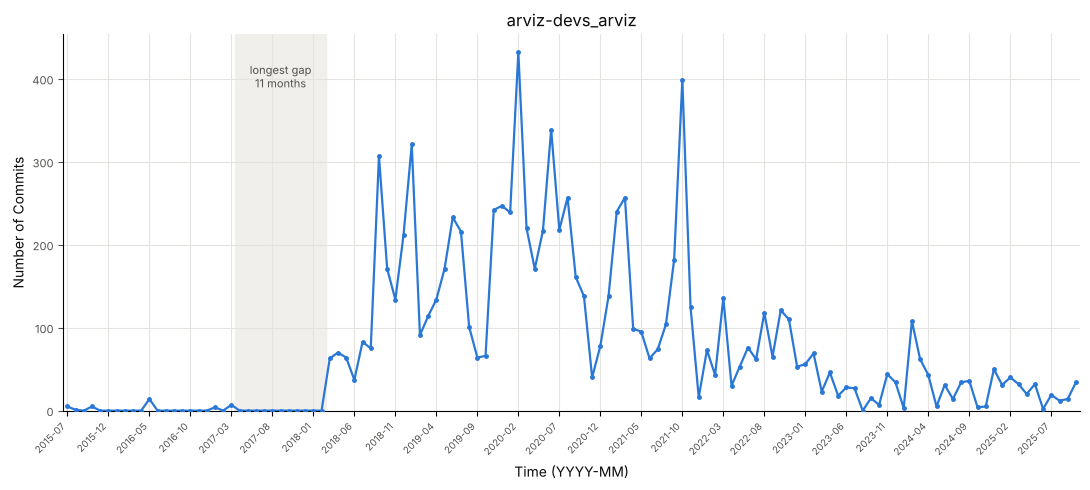

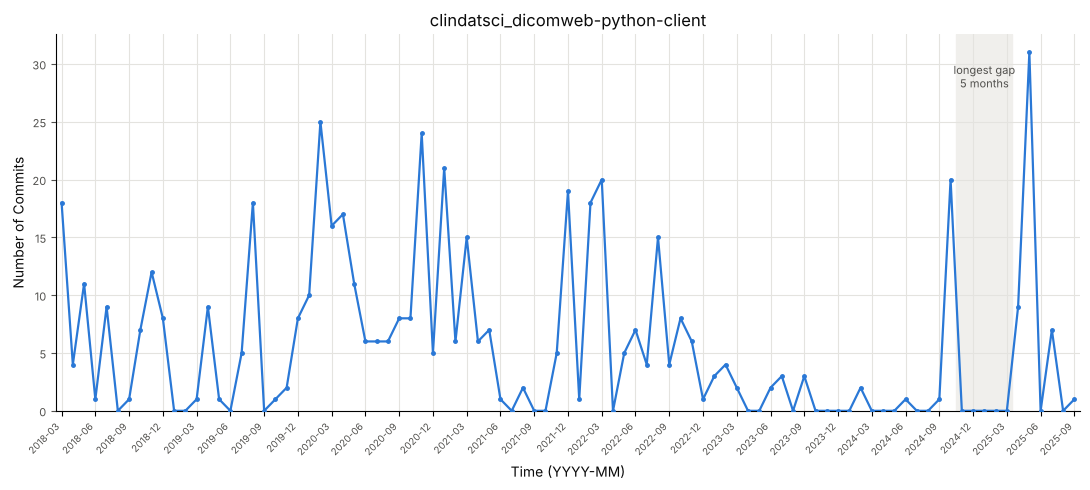

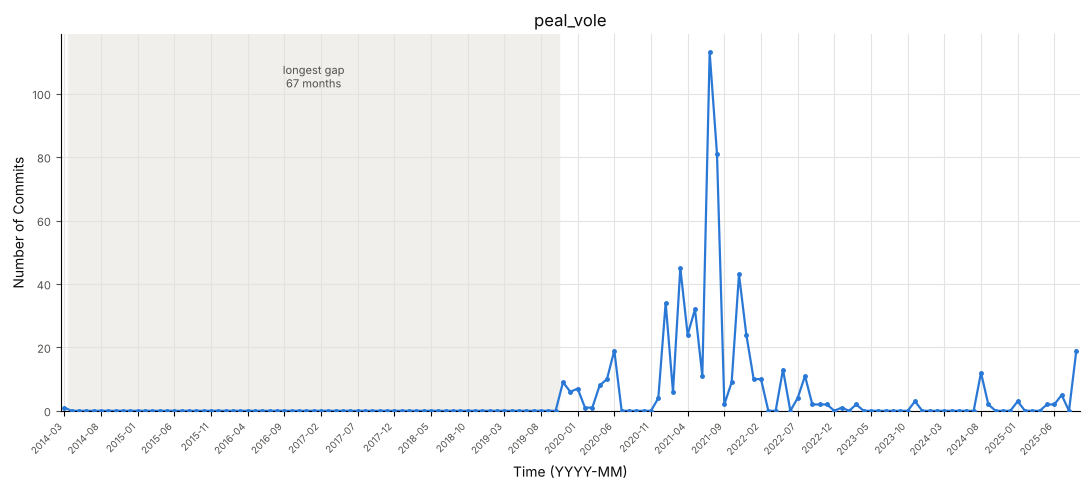

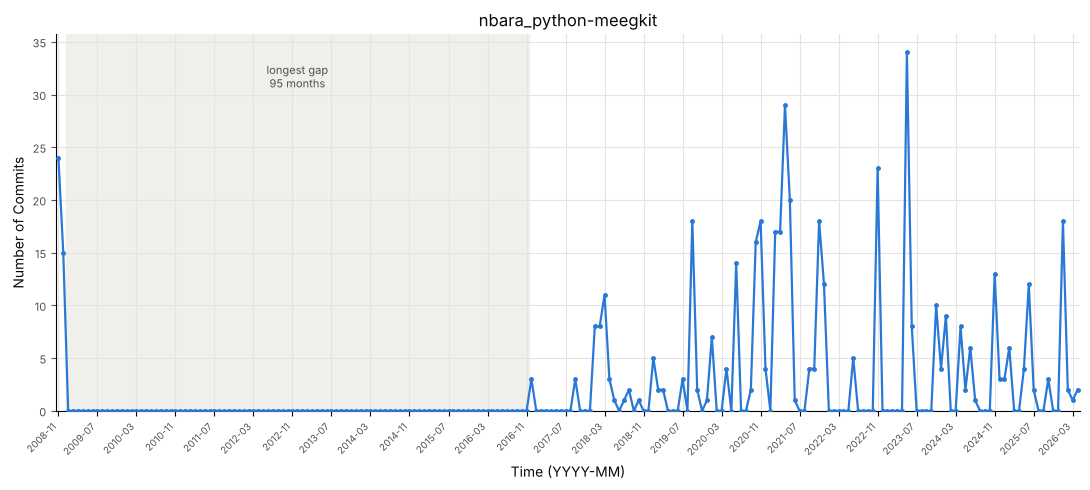

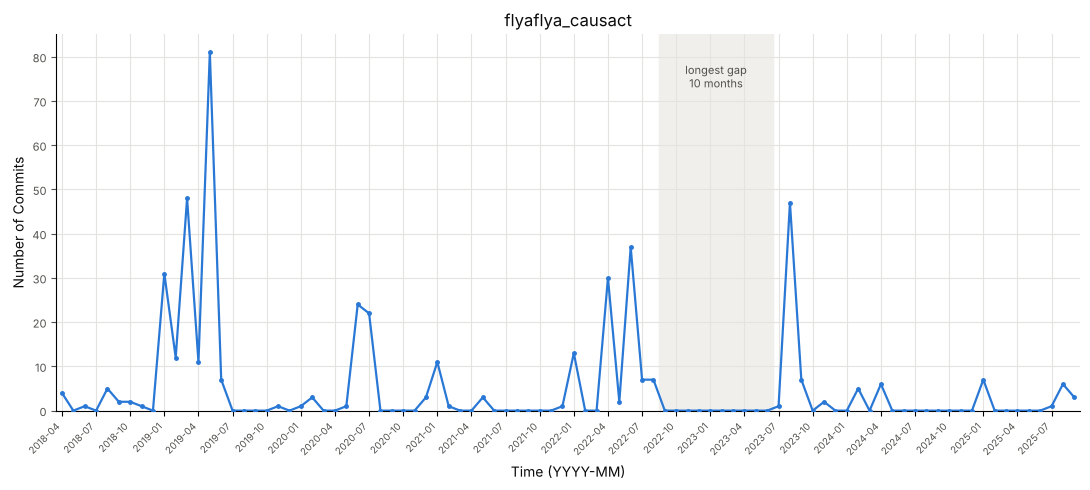

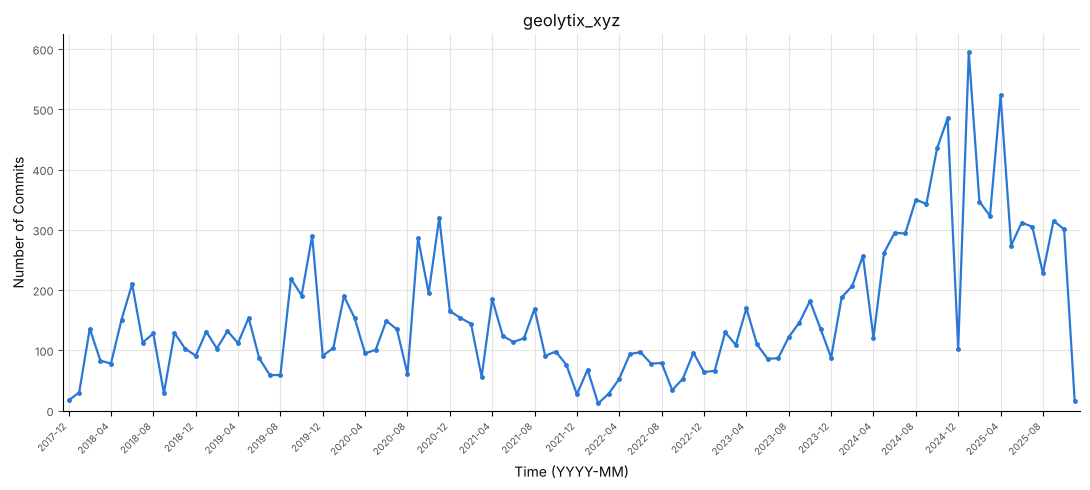

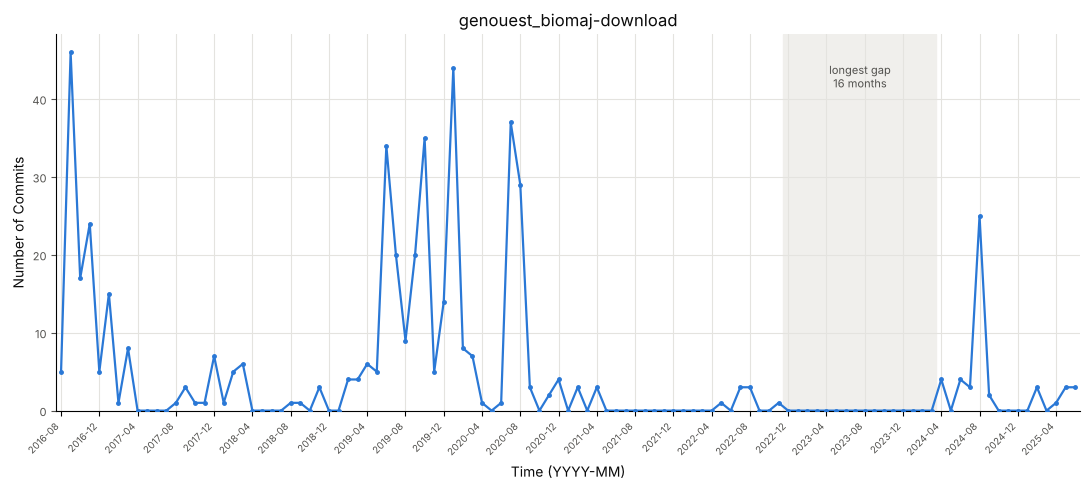

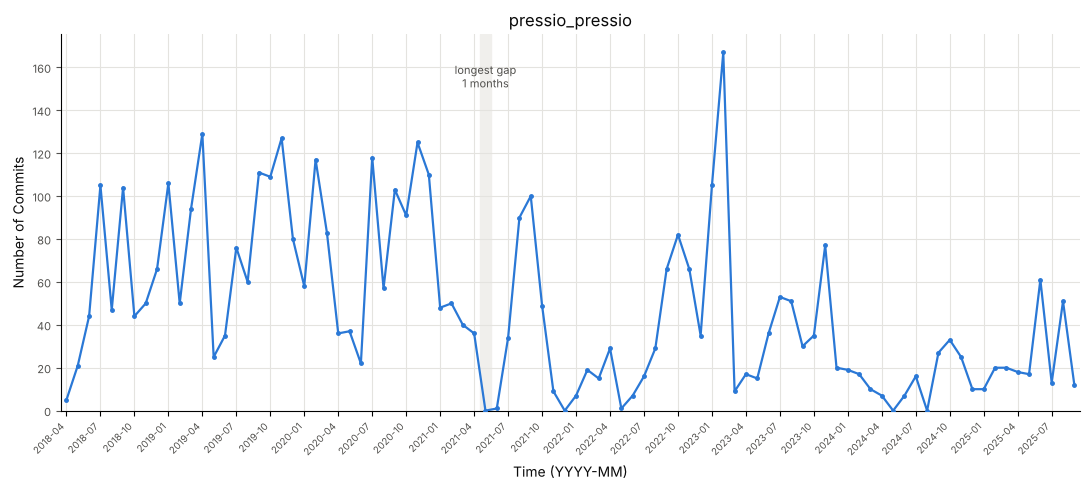

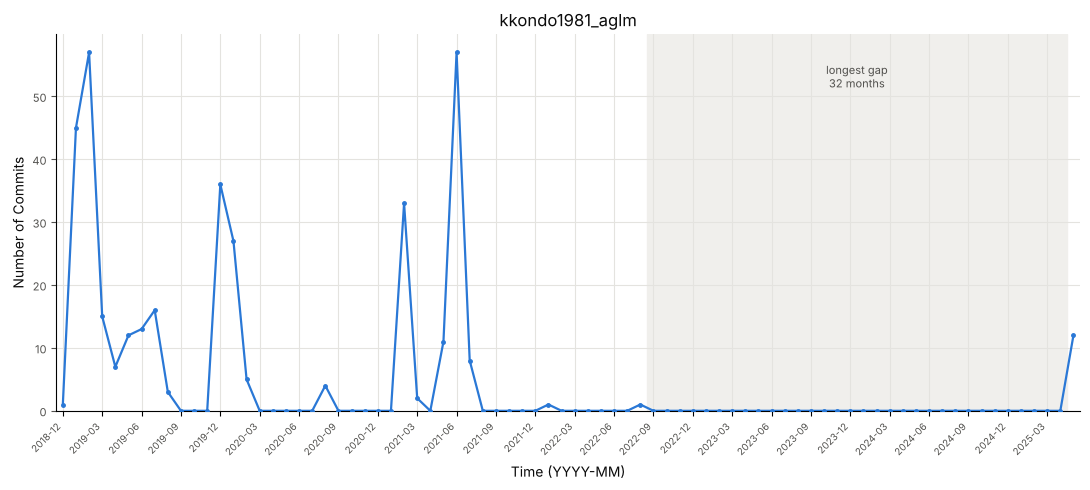

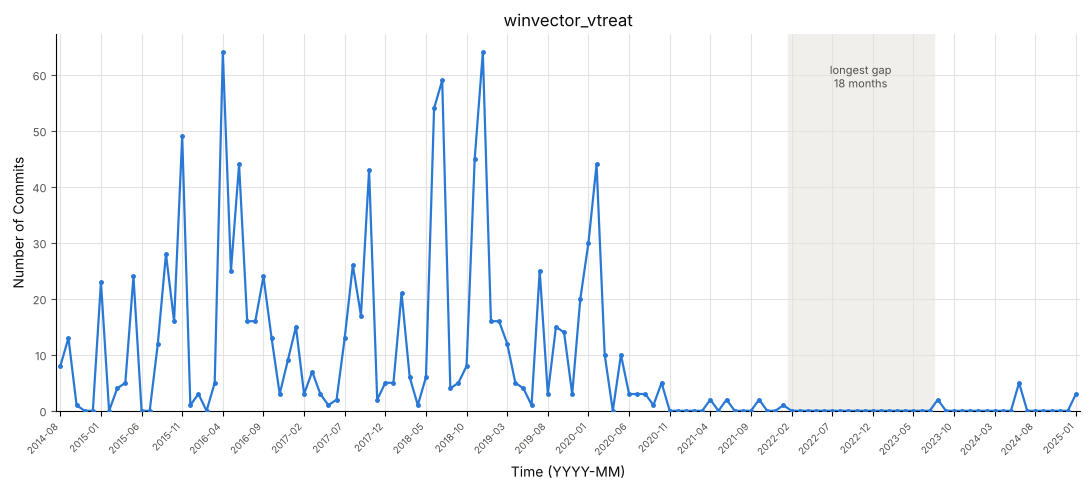

In [6]:
INK, INK2, GRID, LINE, SHADE = '#0b0b0b', '#52514e', '#e4e3df', '#2a78d6', '#f0efec'

def plot_series(prj):
    ts = series[prj]
    x = range(len(ts))
    fig, ax = plt.subplots(figsize=(11, 5))
    g = gaps.loc[prj]
    if g['LongestGapLength (months)'] > 0:
        s = ts.index[ts.Month == g['LongestGapStart (YYYY-MM)']][0]
        e = ts.index[ts.Month == g['LongestGapEnd (YYYY-MM)']][0]
        ax.axvspan(s - 0.5, e + 0.5, color=SHADE, zorder=0)
        ax.text((s + e) / 2, ts['#Commits'].max() * 0.97,
                f"longest gap\n{g['LongestGapLength (months)']} months", ha='center', va='top',
                fontsize=8, color=INK2)
    ax.plot(x, ts['#Commits'], color=LINE, linewidth=1.6, marker='o', markersize=2.5, zorder=3)
    step = max(1, len(ts) // 24)
    ax.set_xticks(list(x)[::step])
    ax.set_xticklabels(ts['Month'][::step], rotation=45, ha='right', fontsize=7, color=INK2)
    ax.set_xlim(-0.5, len(ts) - 0.5)
    ax.set_ylim(bottom=0)
    ax.set_xlabel('Time (YYYY-MM)', color=INK)
    ax.set_ylabel('Number of Commits', color=INK)
    ax.set_title(prj, color=INK)
    ax.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    ax.tick_params(axis='y', colors=INK2, labelsize=8)
    fig.tight_layout()
    fig.savefig(f'{NETID}_timeseries_{prj}.png', dpi=600)
    return fig

for prj in projects:
    fig = plot_series(prj)
    plt.show()
    plt.close(fig)

## Activity pattern (judged from the charts above)

In [7]:
activity_pattern = {'arviz-devs_arviz': 'declining',
 'clindatsci_dicomweb-python-client': 'U-shaped',
 'peal_vole': 'irregular',
 'nbara_python-meegkit': 'irregular',
 'flyaflya_causact': 'irregular',
 'geolytix_xyz': 'rising',
 'genouest_biomaj-download': 'declining',
 'pressio_pressio': 'declining',
 'kkondo1981_aglm': 'declining',
 'winvector_vtreat': 'declining'}

# Interpretation

**A note on the data.** WoC's `p2c` map collects commits from every branch and from forks that WoC attributes to the project, so counts are far above what GitHub shows for the default branch (arviz: 9,492 in WoC vs 1,670 on `main`; geolytix_xyz: 15,306 vs 6,217). 59 of the 33,140 commit SHA1s had no content in WoC's commit store ("Key … not found") and are missing from the summary. Unusual early dates come from imported history, not from bad timestamps (see vole and meegkit below). The last month of each series can be partial because the WoC snapshot ends mid-month (e.g., geolytix_xyz stops on 2025-11-04).

Gaps counted below are runs of **3 or more consecutive months with zero commits**.

| Project | Pattern | Gaps ≥ 3 months | Longest gap |
|---|---|---|---|
| arviz-devs_arviz | declining | 3 | 2017-04 → 2018-02 (11 mo) |
| clindatsci_dicomweb-python-client | U-shaped | 3 | 2024-11 → 2025-03 (5 mo) |
| peal_vole | irregular | 6 | 2014-04 → 2019-10 (67 mo, artifact) |
| nbara_python-meegkit | irregular | 9 | 2009-01 → 2016-11 (95 mo, artifact) |
| flyaflya_causact | irregular | 6 | 2022-09 → 2023-06 (10 mo) |
| geolytix_xyz | rising | 0 | none |
| genouest_biomaj-download | declining | 5 | 2022-12 → 2024-03 (16 mo) |
| pressio_pressio | declining | 0 | 2021-05 (1 mo) |
| kkondo1981_aglm | declining | 6 | 2022-09 → 2025-04 (32 mo) |
| winvector_vtreat | declining | 5 | 2022-02 → 2023-07 (18 mo) |

- **arviz-devs_arviz — declining (3 gaps).** Three gaps in 2015–2017, when the repo was still *mcmcplotlib*, a copy of PyMC3's plotting code. After the March 2018 relaunch as ArviZ, activity rose to ~2,500 commits in 2020, then fell steadily to a few hundred a year (367 in 2023, 236 in 2025) as the library matured. Shape is "rise then decline"; since the 2020 peak the long-term trend is downward.
- **clindatsci_dicomweb-python-client — U-shaped (3 gaps).** Steady activity 2018–2022 (45–142 commits/year), a trough in 2023–2024 (17 and 24 commits) containing all three gaps, then a recovery in 2025 (48 commits) when external contributors added features.
- **peal_vole — irregular (6 gaps).** The 67-month first gap comes from a gh-pages commit dated 2014 (see Part 3). Real work starts 2019-11, explodes in 2021 (424 commits, one month above 100), then drops to bursts separated by 3–8 month gaps in 2023–2025.
- **nbara_python-meegkit — irregular (9 gaps).** The 95-month first gap is imported 2008 history. From 2018 on, activity comes in short bursts (often around releases) separated by 3–5 month quiet periods; yearly totals hover between 28 and 122 with no clear trend.
- **flyaflya_causact — irregular (6 gaps).** Bursts tied to milestones (2019 development, 2022 JOSS paper, 2023 numpyro switch), separated by quiet periods of 4–10 months. Typical single-maintainer R package.
- **geolytix_xyz — rising (0 gaps).** Every month from 2017-12 to 2025-11 has commits. After a dip in 2022 (756), activity climbed to 3,340 (2024) and 3,539 (2025), with near-weekly releases.
- **genouest_biomaj-download — declining (5 gaps).** Strong bursts in 2016 and 2019–2020, then near silence from 2021 (6, 8, 0 commits in 2021–2023), a small 2024 revival for dependency fixes, and little since.
- **pressio_pressio — declining (0 gaps).** Never inactive for even two consecutive months, but volume fell from ~1,000 commits/year (2019–2020) to ~170–220/year (2024–2025), with a spike in late 2022/early 2023.
- **kkondo1981_aglm — declining (6 gaps).** Development bursts in 2019 and 2021, then a 32-month silence and a single CRAN-maintenance burst in May 2025.
- **winvector_vtreat — declining (5 gaps).** Very active 2015–2020 (100–280 commits/year), then collapse to 1–6 commits/year from 2021 with repeated long gaps: a mature package in maintenance mode.


# Part 3.1 — commits before and after the longest gap
Last 10 commits before the gap starts and first 10 commits after it ends.

In [8]:
gap_parts = []
for prj in projects:
    g = gaps.loc[prj]
    if g['LongestGapLength (months)'] == 0:
        continue
    d = df[df['project'] == prj].sort_values('time')
    start = pd.Period(g['LongestGapStart (YYYY-MM)'], 'M').start_time
    after = (pd.Period(g['LongestGapEnd (YYYY-MM)'], 'M') + 1).start_time
    pre = d[d['date'] < start].tail(10).assign(**{'pre/post': 'pre'})
    post = d[d['date'] >= after].head(10).assign(**{'pre/post': 'post'})
    gap_parts += [pre, post]
gap_commits = pd.concat(gap_parts)[['pre/post', 'project', 'commit', 'author', 'time', 'message']]
gap_commits.to_csv(f'{NETID}_project_gap_commits.csv', sep=';', index=False)
gap_commits.groupby(['project', 'pre/post'], sort=False).size().unstack()

pre/post,pre,post
project,,
arviz-devs_arviz,10,10
clindatsci_dicomweb-python-client,10,10
peal_vole,1,10
nbara_python-meegkit,10,10
flyaflya_causact,10,10
genouest_biomaj-download,10,10
pressio_pressio,10,10
kkondo1981_aglm,10,10
winvector_vtreat,10,10


## Commit themes
Each commit gets one theme from keyword rules on the message and author (merge commits are judged by the PR title). I then read every message and corrected the rule's label where it was wrong (`overrides`, keyed by SHA1). Top two themes = the two most frequent; ties go to the theme listed first in the README.

In [9]:
THEMES = ['Feature development', 'Bug fixes', 'Documentation updates', 'Dependency updates',
          'Release', 'Security patches', 'Automated bot contributions', 'Other']
RULES = [
    ('Automated bot contributions', r'\[bot\]|dependabot|pre-commit-ci|github-actions|renovate|^\[pre-commit\.ci\]|^auto(matic|mated)? (format|update)'),
    ('Security patches', r'security|\bcve\b|vulnerab'),
    ('Release', r'\brelease|^v?\d+\.\d+(\.\d+)?\b|bump(ed)? (the )?version|version bump|\bversion \d|changelog|news\.md|\bcran\b|prepare for|\btag(ged)?\b'),
    ('Dependency updates', r'\bbump|depend|requirements|\bupgrade|\bpin(ned)?\b|package(-lock)?\.json|setup\.(py|cfg)|pyproject|environment\.ya?ml|\bdeps?\b'),
    ('Documentation updates', r'\bdoc|readme|typo|vignette|tutorial|example|comment|\bman\b|roxygen|\.rd\b|\.md\b|wiki|license|citation'),
    ('Bug fixes', r'\bfix|\bbug|\berror|\bissue|\bpatch|correct|resolv|crash|broken|\bfail|wrong|\bhotfix'),
    ('Feature development', r'\badd|implement|feature|support|\bnew\b|introduc|allow|enable|extend|improv|enhanc|option|\bapi\b'),
]

def first_line(msg):
    lines = [l.strip() for l in str(msg).splitlines() if l.strip()]
    if lines and re.match(r'^merge (pull request|branch|remote)', lines[0], re.I):
        return lines[1] if len(lines) > 1 else lines[0]   # PR title, else the merge line itself
    return lines[0] if lines else ''

def rule_theme(author, msg):
    text = first_line(msg).lower()
    if re.search(RULES[0][1], str(author).lower()) or re.search(RULES[0][1], text):
        return RULES[0][0]
    for theme, pat in RULES[1:]:
        if re.search(pat, text):
            return theme
    return 'Other'

overrides = {'92271667f7314bf5d9c3247f45809da634019c8b': 'Bug fixes',
 '70642c2326df17be86016ee080c625bbe479f7d0': 'Other',
 'd7570ea6c023feca9753091ba5393a4afbee2ffe': 'Other',
 '29b816d5a9b7800d5c15b94bf1e3e5e760d58b50': 'Feature development',
 'ced24cc4af10e914d2cbd176be179543e6366d05': 'Feature development',
 '41ad693ffe8442c7e3fa95b51f7f4b7b5ddedcc3': 'Bug fixes',
 'ea2e7a26904fa17d314d92329e76a494ec479072': 'Bug fixes',
 'af73fca27ea88b0e5ddc099320a5135ef9fa1026': 'Feature development',
 'ba4ac8eaf29281ce70cc159ee54ccef646a5be36': 'Bug fixes',
 '9a371179dd675fec5f25499a5fe9c761af6d163d': 'Feature development',
 '057a7f4396c0705034a1aa36f2ea359e29b57363': 'Feature development',
 '37fdabe1b2b1ae7deee0746ad34e0ce73c62ce09': 'Feature development',
 '2611d7c5a55ca34b49249dff036100adfebcc6f9': 'Other',
 '632b80c9c39bd81127bef21ca5ecfff50c86ae04': 'Other',
 'f54ad8851b4d05a120743d637de9b5bee4b077a6': 'Other',
 '020e5311aa781dbea6642bebc1e2dc0807e3c63c': 'Other',
 'e3c97d327f43671b35c544349116be64dda390fc': 'Bug fixes',
 '2e86cb9ba9e132ef6b0c16a89adbadae43ed048d': 'Feature development',
 'a3657ac4794fbb5ad4085e69b587a3f86295ea78': 'Feature development',
 '5c75c78c2e1afe675b1c4cb72c533b650c987946': 'Other',
 'c58601c6d432b64ca7bf2b77edc3216a40366269': 'Bug fixes',
 'a0f22754e4e87b4dfae3bddb331bb871a0ca1fc2': 'Documentation updates',
 '1371496dd416557f4e8de0b1f07d9a366eeef02f': 'Dependency updates',
 '4d694cfaccd18ec780e8c459ca01e2ea72a8d365': 'Dependency updates',
 '5d7f42123b0ac3225dafdb993d9d7b2bceb2b82d': 'Dependency updates',
 'bc268778856b78cf3f51c5b50262f294520cd378': 'Dependency updates',
 '1546347d689744b0ca153256a180bd79ceeb6468': 'Bug fixes',
 'ffe6f5bb36d623f30cdc72975e5d6b3884f13176': 'Bug fixes',
 'da0595646d1c98e4406cca3327c3c30a5a176e62': 'Documentation updates',
 '99aa011b428249febdaca1f4ab959453754be961': 'Release',
 '45e4466cc9788eff67ab5a32c2f634b73b4c22ff': 'Feature development',
 '01f7d08ffa7e310c900c79145c53adf0c844366c': 'Feature development',
 '1f637ccf454a2faf926660271324e5e7ce838499': 'Feature development',
 '3d55233aa699c203b1789bfcb07516fcc547c37b': 'Feature development',
 'ff10780c9394cbd1ebaa455920633e8beafc2c75': 'Feature development',
 'e80f54ca0038da49c66423382ab8363aa8313c6e': 'Dependency updates',
 '6867cd686e8d7b770f7382ca57a81a56fda448cc': 'Dependency updates',
 '315ff4168911945c5f21b295f6feaec05ed44f93': 'Bug fixes',
 '823564dcd9d16b7b51f3a7a6cd2aa21cab3a1342': 'Feature development',
 '68ddd1c65080c08c39398ec0bc7e0740b704ca0e': 'Other',
 '9c858f2264beb46885a6c6dd4bd60a4061f9e052': 'Documentation updates',
 '323da60a56a85dbaec6ec78918860394fd4e8565': 'Feature development',
 '92034247e6ac033ccda1a4e3d91a57a7104a4f3b': 'Feature development',
 '8af0063e06c1afd547278a4b9f02e932f7901052': 'Other',
 'f22f3818a08e64b5b2fa31d8e1ca1566e1a50fa4': 'Feature development',
 '82508e75f011d218126fec1fb2f43726f73c1635': 'Feature development',
 'dcd5ed0caff695b582fb552ec0d8ae35ef735f9b': 'Feature development',
 '8b6fd9242fcda665e1d0a9924ed6e301c838467c': 'Other',
 '5527d2b3c432ebb93fe7939e02b22790996ca349': 'Feature development',
 '38fa91072cc445b6e5776f3d04ff0517c7fd7096': 'Feature development',
 '951deaf81123825077c8870fffbb54858d41af0b': 'Feature development',
 '142be751fc125f8f13fef0bdb5638467ff1282d3': 'Feature development',
 '2a991afb87144574e5c2a8b4f11a5334b37969e2': 'Other',
 'f8ceab6cb9c3890cf838da516b8b7a63a2bed265': 'Other',
 '37b7d578688b895de83d3ac6c713a08b6bea458d': 'Other',
 'b6d7429fc985db63d617ce9995ab85c2a8e1aaa5': 'Other',
 '278632199966caba5beac2c890088a8f01d9d093': 'Bug fixes',
 '5079ecff8d8ac3606da0d32cf4e5ee296d07d5ac': 'Bug fixes',
 '924c7d56744bd5138c0fce0179314fff35222e12': 'Bug fixes',
 '581346dfc27082937ef3c160e37a5fa462503229': 'Bug fixes',
 'c344642f3e71db9e480f29b3c2033a469a89282c': 'Feature development',
 '9b499bda46ede35e776808e664ecf4c7f1488221': 'Documentation updates',
 'b0893f44044af97137997c88db13d98d90ab80ef': 'Documentation updates',
 'e8eee3b556e44ff763f3e6c8712b6ec4508cf423': 'Other',
 'a98387664a194cf95418046edc66e4772f92998a': 'Other',
 '2b0e6cd629af192e6bbce7e75beee208c43c5fb0': 'Other',
 'd7e14d956ccc8d5609d8676a650016f3cb79f912': 'Other',
 '1fc6b46804d91a529ef166b95fe76eaf493fb6b0': 'Bug fixes',
 'c388f35ff651854932731239cc0dfca7a1eba185': 'Bug fixes',
 '346e586516c5a35a7b5583cde713ca9b505efdfc': 'Other',
 'a98ab0798a86e8c5308d378567ffbc0054e9f928': 'Feature development',
 'b9551cfb45e45d86770aaf9f72795ddec558dc6b': 'Documentation updates',
 '507c1595a000ab589c3c1902bee90de506bc6e42': 'Documentation updates',
 'c79a68c7edca406fae3d2dfe93922be7d803efaf': 'Documentation updates',
 'e8eb4da729bdeb589bb0ad4985c5e429e5cc92aa': 'Release',
 'ccf8c5364a4b6219dc8d89b178b4e6f74840d66a': 'Release',
 'ff6bad8d0184c9838e8ec088bfa548f8cbd1ff55': 'Documentation updates',
 '2641cfca83610064ed579d2c2241224135e0ef3f': 'Release',
 '65c3ae2f7357e07f0acbe427daf016e67e998518': 'Release',
 '6e96f6f667e9e5f792ed14ae3c060255098a891c': 'Release',
 'b7d886a0f253f5b6540b0687f7da0f47e39ce191': 'Documentation updates',
 '864285fe79328a3c70187d33b228ea7c53eaa4a9': 'Feature development',
 '2654a38f1647c3ecd5bd2fe9263e4c9e98065b67': 'Dependency updates',
 '0bc835a736aa8316c456d06fdcd92fc2639ecc40': 'Feature development',
 '1fc5bc523ccee592a30c3ab626e278091bc4ef96': 'Bug fixes',
 'a0d4f6e111cea34e9f8116ab0a4c0fe7ed4633ea': 'Feature development',
 'd09c26ea845d991142849326d5da60470ce9e1ae': 'Feature development',
 'edf7d35de6152ab327c0e1914a99fc65a97b13a5': 'Feature development',
 '1ac0162051da306a1eb5bffeefdcba65e7ef2525': 'Feature development',
 'f191445908a134237d16f403764936010688ccc2': 'Documentation updates',
 '413db7995bf5109166728be9510d375d09e54db0': 'Documentation updates',
 '0fe49195b9459078cdcf0f304fc0e8999c75391b': 'Other',
 'f1f04e6ffa9bb845ba3bcd592eab1e88e7ab145e': 'Other',
 '243e3b3b2efd49d8527fcae840a96570728a271b': 'Dependency updates',
 '30d3e676917d24df71eadf6a0babc8d393899280': 'Bug fixes',
 '7eb13c58ddc37bc47ad481aaf472b22350b5c329': 'Bug fixes',
 'f86f7a40f7b4487ec4e121e8f5528894c1dfb44c': 'Release',
 '54a60f3268e8f60d35f1e23395921265dbf931c7': 'Dependency updates',
 '9ebdc2b82b9ae24107952e8effd257e5f13aca50': 'Dependency updates',
 '81e8b09886778bb21fe9ee9625ea96edfda6b8bc': 'Release',
 '709da84d9dbf42c31ddedec39ba34f079a6bb768': 'Bug fixes',
 'b140ad8e074f368e3e371fb144821637d79c1f45': 'Dependency updates',
 'bb3fa9b58a0a9acbe4cac02966c0451c03fa0b4b': 'Dependency updates',
 '97e1f3d3bc6a0c72c33c05ce54f425c3f4262b9d': 'Dependency updates',
 '5c95e7a369ebca0d280707f87a719db3ad7705d7': 'Bug fixes',
 'cc6b469da91117cbb36b3957bc9a9f0a02f96175': 'Dependency updates',
 'dd71561b93fe6b4d8c31e8615950af2d3a4cf2af': 'Dependency updates',
 '2ebd74653ad1481ba31081607b99d8e45db6346e': 'Dependency updates',
 'c3d066aae7ce10f4513bd2d81c715e1924605d27': 'Dependency updates',
 'cad3068a00db98bb94486c3334ac2a4a1ecc3eac': 'Dependency updates',
 'c33f96bd819c4a693edafa4d0351e182b182d50c': 'Dependency updates',
 'fcf865c98c2111836da348bb7e09ffc2ceda9a59': 'Documentation updates',
 '9276dffa1e21eee74dc979931056f90b05024d95': 'Release',
 '01bec402bf4f1e575275313084777e1f8af1bda9': 'Bug fixes',
 '9c9df10d7e47598ff31461bcf3a5762adb08fffa': 'Documentation updates',
 '846cf5ae746db73fc386108b8186c5577075a251': 'Other',
 '65698de6e9fef7c0130784f22fec0ed7f4e9f9cd': 'Other',
 '073365e9d65624e80fa0cdbc71983a4d5a0d944d': 'Other',
 'ebe5553816e54f0f96fec0a9891d17e760057fd0': 'Bug fixes',
 'f98b921615d5c3bfeea79c79b680657cc38e4d2c': 'Bug fixes',
 '2ae94d68bf585cb67d3deeba11a3b45a0795a59a': 'Release',
 '39c62187106eddf49e43bd82a0d2e87828b9fe8c': 'Documentation updates',
 '1cfc8031fb82607829d18810a2d944269da91c63': 'Feature development',
 'bf845e77975bb358c2f7b101c2ab5b44c0d56dd3': 'Feature development',
 '9dcfa71df562218df451fb274a4f67f720bbcccc': 'Other',
 'cebc39f1a8d5c50f886334a99d5f141faa103a99': 'Other',
 '5e9a69420a1f95f7492e722253b71ca9e0e19b98': 'Other',
 '85301b563df17d007fe70150532af78154b885d0': 'Other',
 '07bcddd4ba0c3f680e3f138f7899b6b0900afef5': 'Other',
 'a4b334e76a9a46105cac0ac12a0d5cf3a5a51e15': 'Feature development',
 '26b8dd8fe13b13e59bfa9c9b18c32818b975655a': 'Other',
 '669e275ff7e35c234c789c544a200b491652fbd2': 'Feature development',
 '22363999110e195dccdd6e99b8d31d9037d42664': 'Feature development',
 '04e3cd5bc100f1be6a33a93d3dd5ffc0e8fb7412': 'Feature development',
 'eba08eadeee05e22a1a4828dae3d3cccef29bc11': 'Feature development',
 '249c5d43b0b62c6a89ed13dbe2e25f5a9850bc15': 'Feature development',
 'd45a31cb366c6228dd4a33494e48bfee4be28288': 'Feature development',
 'b1785e2b699089f54e8ca66f991be07e03b16f61': 'Feature development',
 '7e82be442ccb34ac23c0f13befd763b4f18f3d25': 'Feature development',
 'e0a95204f606d521b34568b020e9b91c0a815d6b': 'Bug fixes',
 '8a326a20dca48e2cf101e6a6c22cb0c7b4ea4126': 'Bug fixes',
 '606dbe8d54ebf8b9cf13b90c3a68b2376cf7c6ed': 'Release',
 'b6a96135b1f6e929fd44727fa2bfcfac84075f67': 'Release',
 '1e0c919ceab66cca12a057b1596f5717cd176e53': 'Other',
 'b0c219acc488b37a54973ca8f5ead599724093a4': 'Bug fixes',
 '92912575407292a9ca0d90b47d85eac3c2c8ae95': 'Bug fixes',
 '31f099655d278d25735b6f6570b453628eee372d': 'Release',
 'ac3334a93e243ad6c4fd5546ee15aebb98b9a2ff': 'Bug fixes',
 'f817bce00bffaa40c964ebb57d0138f0eb5ec8a3': 'Bug fixes',
 '23f2d13c1c09baabc28ed07bc738f41a88a23617': 'Bug fixes',
 'f92ffd3999fd94f9029e1623a824f3686f9450c7': 'Bug fixes',
 'af30d1f4433563fc6a93a611e7e11f0e31a2fd79': 'Documentation updates',
 '61f32ce7296f2df19d0e739ad875d2fb8555c106': 'Documentation updates',
 '9d10cb21fe6cf104d6a97a55fff6bc22c85bb5c4': 'Documentation updates',
 '07bd653045346e10509afc527c2af6b2e3bd9ccd': 'Documentation updates',
 '7874185347b3cb74f2a4690d1bd182311d794c8c': 'Documentation updates',
 'ca67f56d4c975e3c4bfb6a89faafde6510d83bc1': 'Release',
 '86777b87cb8597f7b166b4a3cc8c4a4b6f7ee7fa': 'Release',
 '84c28442bf2ea0441eb161c1119f79a2edb07be9': 'Documentation updates',
 '81f8128b745f5beddf49b4a2eaede9f137288c03': 'Documentation updates',
 '59c36629badd5866c8ce5af781649e70d0717836': 'Documentation updates',
 '00dae9e1b7a09f90aaa5dee9935165fbb94de901': 'Release',
 '7ee77dcef3082a9e791aa8f0d764d8910b12b326': 'Release',
 'eaba23d094e9ac2edeb439fb30a6f179a4aca20a': 'Documentation updates',
 '74757ccb71054f3b2646f81a0b0b40b264502860': 'Dependency updates',
 '7635228a1941573fda62fbfc06b117a0737c5c98': 'Release',
 '13305bd26d1cd3e8c7b57583513d0ea99528b0c2': 'Documentation updates',
 '9e28ee2eae4fa93db6b7bdc67b02dfcdc021ce61': 'Documentation updates',
 '00a672f1d23eaae05023214829e1d80e2e5e95f0': 'Documentation updates',
 'c5b5a90e0a353282592748d8020dac03a21cb4cb': 'Documentation updates',
 '6fa2eb97db74b1bfbde90cb0cfa8e2715fb20842': 'Documentation updates'}

def theme(row):
    return overrides.get(row['commit'], rule_theme(row['author'], row['message']))

def top2(themes):
    counts = pd.Series(themes).value_counts()
    order = sorted(counts.index, key=lambda t: (-counts[t], THEMES.index(t)))
    return ':'.join(order[:2])

gap_commits['theme'] = gap_commits.apply(theme, axis=1)
themes = gap_commits.groupby(['project', 'pre/post'])['theme'].apply(top2).unstack()
themes = themes.rename(columns={'pre': 'BeforeThemes', 'post': 'AfterThemes'}).reindex(projects)
themes

pre/post,AfterThemes,BeforeThemes
project,,
arviz-devs_arviz,Other:Feature development,Feature development:Bug fixes
clindatsci_dicomweb-python-client,Feature development:Dependency updates,Dependency updates:Bug fixes
peal_vole,Feature development:Other,Documentation updates
nbara_python-meegkit,Other:Bug fixes,Bug fixes:Other
flyaflya_causact,Feature development:Documentation updates,Documentation updates:Release
geolytix_xyz,NaN,NaN
genouest_biomaj-download,Dependency updates:Bug fixes,Bug fixes:Dependency updates
pressio_pressio,Other:Feature development,Bug fixes:Other
kkondo1981_aglm,Bug fixes:Release,Feature development:Bug fixes


# Part 3.2 — who drove the recovery, current status and recent themes
Authors of post-gap commits are compared with everyone who committed before the gap (matched on name or e-mail, since people commit under several addresses).

In [10]:
def ident(author):
    m = re.match(r'\s*(.*?)\s*<(.*)>', str(author))
    name, email = (m.group(1), m.group(2)) if m else (str(author), '')
    return ' '.join(name.lower().split()), email.lower().strip()

def is_bot(author):
    return bool(re.search(r'\[bot\]|dependabot|pre-commit-ci|github-actions', str(author).lower()))

recovery = []
for prj in projects:
    g = gaps.loc[prj]
    if g['LongestGapLength (months)'] == 0:
        continue
    d = df[df['project'] == prj]
    start = pd.Period(g['LongestGapStart (YYYY-MM)'], 'M').start_time
    after = (pd.Period(g['LongestGapEnd (YYYY-MM)'], 'M') + 1).start_time
    before_ids = [ident(a) for a in d[d['date'] < start]['author'].unique()]
    names = {n for n, _ in before_ids}; emails = {e for _, e in before_ids if e}
    post = d[d['date'] >= after].sort_values('time')
    first10 = post.head(10)
    humans = [a for a in first10['author'].unique() if not is_bot(a)]
    returning = [a for a in humans if ident(a)[0] in names or ident(a)[1] in emails]
    new = [a for a in humans if a not in returning]
    all_post_humans = [a for a in post['author'].unique() if not is_bot(a)]
    recovery.append({'project': prj,
                     'first post-gap commit': post['date'].min().strftime('%Y-%m-%d') if len(post) else 'none',
                     'returning authors (first 10)': '; '.join(returning),
                     'new authors (first 10)': '; '.join(new),
                     'post-gap authors (all)': len(all_post_humans),
                     'of whom new': sum(1 for a in all_post_humans
                                        if not (ident(a)[0] in names or ident(a)[1] in emails))})
pd.DataFrame(recovery).set_index('project')

,first post-gap commit,returning authors (first 10),new authors (first 10),post-gap authors (all),of whom new
project,,,,,
arviz-devs_arviz,2018-03-06,aloctavodia <aloctavodia@gmail.com>; Osvaldo M...,,391,379
clindatsci_dicomweb-python-client,2025-04-28,,Sumantra Sharma <sumantra94@gmail.com>; Kai Sc...,8,5
peal_vole,2019-11-14,,Chris Jefferson <caj21@st-andrews.ac.uk>,7,6
nbara_python-meegkit,2016-12-15,,nbara <nbara@users.noreply.github.com>; nbara ...,43,43
flyaflya_causact,2023-07-31,Adam Fleischhacker <ajf@BUEC-0F00TVX.win.udel....,,3,0
genouest_biomaj-download,2024-04-19,,Remy Siminel <95074810+rsiminel@users.noreply....,7,5
pressio_pressio,2021-06-22,Francesco Rizzi <fnrizzi@sandia.gov>,Mikołaj Zuzek <mikolaj.zuzek@ng-analytics.com>,24,13
kkondo1981_aglm,2025-05-11,Kenji Kondo <kkondo.odnokk@gmail.com>; Kenji K...,,2,0
winvector_vtreat,2023-08-19,John Mount <jmount@win-vector.com>; Nina Zumel...,,2,0


### Current status and recent themes from GitHub
WoC stops in early 2025, so the latest commits come from each GitHub repository's default branch (history-only clone, no file contents downloaded).

In [11]:
import os
os.makedirs('gh_clones', exist_ok=True)
recent_rows, status = [], {}
for prj in projects:
    repo = github.loc[prj, 'repo']
    path = os.path.join('gh_clones', prj)
    if not os.path.exists(path):
        subprocess.run(['git', 'clone', '-q', '--filter=blob:none', '--no-checkout', '--single-branch',
                        f'https://github.com/{repo}', path], check=True)
    log = subprocess.run(['git', '-C', path, 'log', '-10', '--format=%H%x1f%an <%ae>%x1f%ct%x1f%B%x1e', 'HEAD'],
                         capture_output=True, text=True, check=True).stdout
    for rec in filter(None, (r.strip('\n') for r in log.split('\x1e'))):
        sha, author, t, msg = rec.split('\x1f', 3)
        recent_rows.append({'project': prj, 'commit': sha, 'author': author, 'time': int(t), 'message': msg})
    last = pd.Timestamp(github.loc[prj, 'lastGHCommitDate'])
    # README rule: commits in the 6 months before 2025-09-30 -> Active. Commits made after that
    # date also mean the project was active at the reference date unless it had already stalled, so
    # use the newest commit on or before STATUS_AS_OF.
    asof = subprocess.run(['git', '-C', path, 'log', '-1', '--format=%cs', f'--until={STATUS_AS_OF:%Y-%m-%d} 23:59', 'HEAD'],
                          capture_output=True, text=True).stdout.strip()
    status[prj] = 'Active' if asof and pd.Timestamp(asof) >= STATUS_CUTOFF else 'Inactive'

recent = pd.DataFrame(recent_rows)
recent['date'] = pd.to_datetime(recent['time'], unit='s')
recent_overrides = {'d96624e7853595f4a583b5bd839d5dc118e785b7': 'Automated bot contributions',
 'd5e42b1d51134195d6b29542dcfc13fdf20726ef': 'Documentation updates',
 '2de05e6fc29b0d26f8d12cba046516e0e5f95621': 'Documentation updates',
 'dbd191cf4813e869aaa84c19b5d5485a6c7d223f': 'Documentation updates',
 'ad133eaf3ad364cded7280aa1c03567d3866bd38': 'Other',
 'e7d25ac5e66bb37ea65d892f666c71fd601f6e62': 'Documentation updates',
 'b70e71c47eb7821efe28127663dbfcac2f912893': 'Documentation updates',
 'bd8695f0a8cdee3d063c1dad68263781fce35439': 'Release',
 '4712be4bfb00756d88f8d802a0bb3eb350bee124': 'Documentation updates',
 '654510db8eafe3d6ad3d01342000040291982146': 'Automated bot contributions',
 '056ccd026465710273ad8b8de466b0edc0607a18': 'Bug fixes',
 'f50060575cc261d9835e4cfdbf2e5db5db2f9e76': 'Bug fixes',
 '5cc7ed2f697d4ac32ae2e53ef94cc41921535b9c': 'Bug fixes',
 'd577defb734395708394f079356d688d6e051d74': 'Bug fixes',
 '4a2f52d3334808efaed89efd16f1ea479ff29fc5': 'Bug fixes',
 '46e38d3ccb9d5772f2a4df578879f15da217a9e1': 'Bug fixes',
 '2e6c3ef6b5ee93f54b6ac43df84184a10f89b2dc': 'Bug fixes',
 '6ac26a3797972edc5f3766ea5cf6cd773f566687': 'Bug fixes',
 'f48e5ca22391c1e0e2477b174898e88db834d6e6': 'Feature development',
 '975e4dd583d37b8e1bf68a3bdf2ce04a0d8b124c': 'Dependency updates',
 'd50610e3d923a4f805e8d16dcde3c6db01c6f019': 'Release',
 'c9cfa4cfcc929b5626bc875a8a963eb667b7071f': 'Dependency updates',
 '6c2b714c9cbfe3c9277f58713adfe67e74c6dee0': 'Dependency updates',
 'c181b2972c82841383b8b8a506bc5288dfb57528': 'Release',
 'f67c54da39b53428a05ab462c5b91d85cfa13ca7': 'Release',
 '5a846258ee8627044c5cedc2cd8f1183ac75568c': 'Release',
 '63e47d1c26deed817b5b0f696ef496515496d71b': 'Bug fixes',
 'fac02cbdeccf205385e893cd81a0f6723368c0b2': 'Bug fixes',
 '4ff92bf37d214f24f1d31aa453f3637aca24ff8a': 'Bug fixes',
 'c6e82f759465395374655235d079549e79bea889': 'Dependency updates',
 '3b393f1cda023e561451099e676fd25b20155178': 'Bug fixes',
 '3de17b8b0e97d75f038e9e818eaefc6090201503': 'Bug fixes',
 '97bb9777185464ce9b37bfdda5eb13f022237036': 'Bug fixes',
 'cc65f245c133311f089aa98c20c8c8c3b72eee0d': 'Bug fixes',
 'b23668c6e474f7eb0428f827ec80e72aa80c63fd': 'Other',
 'a362bc69a3a4967af4b0ca8d1640591ed07dbe5d': 'Feature development',
 'bf7f4f4601f57bcc54e45447f5c09991c6d65425': 'Feature development',
 '744f1964ca3a3725ca1e50054cb325c89bd2c2d3': 'Feature development',
 '94431559580ca00f340946bae36caf057670eece': 'Other',
 '0cd068d7bb792bf8b2071aafbf371c6db4cc2a3e': 'Other',
 '6d3dacc44dad5504f6ad416099de920e3ec35a66': 'Release',
 'dcd03630e1c901d8d3dfd449f1fefdd848f95ad3': 'Release',
 'd5633e4928381d20d19790829818a3c085afb559': 'Bug fixes',
 '2d9cb040d03d2069f715fea00f42a5873b857cb9': 'Bug fixes',
 '4b0da66bda7f032cf9388720d0966af9bf626567': 'Feature development',
 '32dcc0d7aed09ec7dca8320ffebfaeaad3382699': 'Bug fixes',
 '0167067aa7bea79e35c04ceab4fa961d23140884': 'Other',
 '57f7ff56207598e80f2b79e87b4d491bfc5a7a3a': 'Release',
 '44a2604f46d1583ac3605f4c5c001d944846e34a': 'Feature development',
 '2443b7d43d27c56434f1af054eff50c17c2b54e3': 'Bug fixes',
 '5f25d77f627a1d498cea77744a93f71bb6045de9': 'Release',
 'dc5c3b58e6da86f54ede86a1260df933f579a85d': 'Bug fixes',
 'f92ffd3999fd94f9029e1623a824f3686f9450c7': 'Bug fixes',
 '23f2d13c1c09baabc28ed07bc738f41a88a23617': 'Bug fixes',
 'ac3334a93e243ad6c4fd5546ee15aebb98b9a2ff': 'Bug fixes',
 'f817bce00bffaa40c964ebb57d0138f0eb5ec8a3': 'Bug fixes',
 '31f099655d278d25735b6f6570b453628eee372d': 'Release',
 '92912575407292a9ca0d90b47d85eac3c2c8ae95': 'Bug fixes',
 'b0c219acc488b37a54973ca8f5ead599724093a4': 'Bug fixes',
 '1e0c919ceab66cca12a057b1596f5717cd176e53': 'Other',
 '7f1b3e0cdce57d7e987106a42f505d13064c3339': 'Bug fixes',
 '6b6c1d7f5bb90bedb9d9591097906e0684a14e0b': 'Automated bot contributions',
 '8c9d44963e88140931ab8287e71611a6a010fb67': 'Documentation updates',
 '2c09b8ff7479a826e4443389c7211461b8e3956a': 'Release',
 '380556c5ea097510047007128e16dc2560c0e3a9': 'Automated bot contributions',
 '5f507e6e63d82cdd8b53c6c7aad56f2888ea33ef': 'Bug fixes',
 '72054a4d7323f31867cd679453b8631ae1cee047': 'Bug fixes',
 '1ae2321fbdc767bed113ebb87357855f5615d0a6': 'Bug fixes',
 'cbc8943fe99d0fbee37ae69acbc900bc8901a572': 'Bug fixes',
 'f71758db5137702f4a9121acb38a5a474e7a2b32': 'Bug fixes',
 '37df59049f4e40ce9b1dde3ca4a0544984dba2dc': 'Other',
 '1f077c5a84987da5b341558859b248cd4d1a7165': 'Documentation updates',
 '7d197c3f167841cd53033fdf5ce9d8022102c11a': 'Dependency updates',
 '631f6d8125d8952da6711cfce9954cd16aa4f9a7': 'Other',
 '37e7b6164fd5e5f0b6b3796deb3b518e7d197fcc': 'Feature development',
 '1bcf6c28a60682ee4325f97e6a8aa2e03fd4b871': 'Feature development',
 'eb64ebe9d86ca25fa0f9e4b12802d22d58650be8': 'Feature development',
 '4ed737e286308331a87e7b8a73f0bd38d0104b97': 'Feature development',
 '67a2b476acce79c8c53d632ebe5984a3b1caf21f': 'Dependency updates',
 '42e69408734b127690d25bf821a13f23180db1f4': 'Other',
 '4382daa9ccd4792b96dd634c2e1890431c965999': 'Bug fixes',
 '002b121477eb60e584d38cd0c84f9c02f0a1bc58': 'Bug fixes',
 'e4fbd3453c31e613665f99fd12a91362bcd8323e': 'Other',
 '314cfb2bfe340b11da67d3f313ba917f2ff4e655': 'Other',
 '70d65513b0f4659a05a7c04f51aefa0fa7a3779b': 'Release',
 '2707cd69ff0b418b2a8b98425a567b055bebb304': 'Release',
 'c3e5913203283eacce3e647454b6232a6ed60bb7': 'Dependency updates',
 'ecf09b268a81e7cfdf51f0a8a6fad47986070f6e': 'Dependency updates',
 '3617fcc394bf5e5bbeb137396f84391cb46dd6a8': 'Other',
 'a6dd77c1da84462eedd1e29d563d576dfa7d95e0': 'Other',
 '6fa2eb97db74b1bfbde90cb0cfa8e2715fb20842': 'Documentation updates',
 'c5b5a90e0a353282592748d8020dac03a21cb4cb': 'Documentation updates',
 '00a672f1d23eaae05023214829e1d80e2e5e95f0': 'Documentation updates',
 '9e28ee2eae4fa93db6b7bdc67b02dfcdc021ce61': 'Documentation updates',
 '13305bd26d1cd3e8c7b57583513d0ea99528b0c2': 'Documentation updates',
 '7635228a1941573fda62fbfc06b117a0737c5c98': 'Release',
 '74757ccb71054f3b2646f81a0b0b40b264502860': 'Dependency updates',
 'eaba23d094e9ac2edeb439fb30a6f179a4aca20a': 'Documentation updates',
 '7ee77dcef3082a9e791aa8f0d764d8910b12b326': 'Release',
 '00dae9e1b7a09f90aaa5dee9935165fbb94de901': 'Release'}
recent['theme'] = recent.apply(lambda r: recent_overrides.get(r['commit'], rule_theme(r['author'], r['message'])), axis=1)
recent.drop(columns='date').to_csv(f'{NETID}_recent_commits.csv', sep=';', index=False)
recent_themes = recent.groupby('project')['theme'].apply(top2).reindex(projects)
pd.DataFrame({'Currentstatus': pd.Series(status), 'RecentThemes': recent_themes})

,Currentstatus,RecentThemes
arviz-devs_arviz,Active,Documentation updates:Automated bot contributions
clindatsci_dicomweb-python-client,Active,Bug fixes:Feature development
peal_vole,Active,Feature development:Other
nbara_python-meegkit,Active,Bug fixes:Automated bot contributions
flyaflya_causact,Active,Release:Bug fixes
geolytix_xyz,Active,Bug fixes:Release
genouest_biomaj-download,Active,Bug fixes:Feature development
pressio_pressio,Active,Other:Bug fixes
kkondo1981_aglm,Active,Bug fixes:Release
winvector_vtreat,Inactive,Documentation updates:Release


## Gap interpretation (evidence in the reflections and below)

In [12]:
interpretation = {'arviz-devs_arviz': {'HypothesizedGapReason': 'Pre-history as a side project: the repo was still '
                                               "'mcmcplotlib', a standalone copy of PyMC3's plotting and "
                                               "diagnostics code (README in 2017: 'Python package to plot "
                                               'MCMC samples ... Looking for a volunteer to register package '
                                               "on pypi/conda'). The last pre-gap commit (2017-03-18) is "
                                               "'update to pymc3's plots stats and diagnostics'. With no "
                                               'release or users and the real plotting code living inside '
                                               'PyMC3, work on the copy stopped.',
                      'HasRecovered': 'Yes',
                      'WhyRecovered': "Decision to make it a backend-independent library: 2018-03-06 'begin "
                                      "pymc3-independence process', tests and traceplot added the next day, "
                                      'README renamed to ArviZ on 2018-03-23 (PR #34), first release 0.1.0 '
                                      'in 2018-09.',
                      'WhoRecovered': 'Restarted by the same person, Osvaldo Martin (aloctavodia), with '
                                      'returning Ari Hartikainen. Growth came from new people: Agustina '
                                      'Arroyuelo (from 2018-04), Colin Carroll (2018-05), Ravin Kumar '
                                      '(2018-08), Oriol Abril (2018-11). 320 distinct authors after the gap '
                                      'vs 7 before.',
                      'Notes': "The 11-month gap is the project's pre-history as 'mcmcplotlib', not "
                               'abandonment; the March 2018 relaunch as ArviZ by its original author, '
                               'quickly joined by many new contributors, ended it. Activity peaked around '
                               '2020 and has declined since as the library matured, but it is still Active '
                               'with frequent releases (v1.0.0 in 2026).'},
 'clindatsci_dicomweb-python-client': {'HypothesizedGapReason': 'Post-release lull in a mature library: '
                                                                'October 2024 work modernized packaging '
                                                                "('Move to pyproject.toml, add support for "
                                                                "3.11, 3.12, 3.13') and shipped "
                                                                "v0.59.2/v0.59.3 ('Version bump for "
                                                                "release', 2024-10-22). The maintainers "
                                                                '(Chris Bridge, Steve Pieper) work on it on '
                                                                'demand, and nothing was requested November '
                                                                '2024 to March 2025.',
                                       'HasRecovered': 'Yes',
                                       'WhyRecovered': 'Downstream users needed features: developers from '
                                                       'openradx, who use the client in their ADIT project '
                                                       '(PR #108 discussion), added optional query '
                                                       'parameters to the search/retrieve/store/delete '
                                                       'methods (issue #105, PR #108, merged 2025-05-13) and '
                                                       'modern tooling; maintainers released v0.60.0 on '
                                                       '2025-05-24.',
                                       'WhoRecovered': 'Mostly new contributors: Sumantra Sharma (19 '
                                                       'commits), Kai Schlamp (9), Jaya Krishnan S R (6), '
                                                       'Lachlan Newman (1). The returning maintainers Chris '
                                                       'Bridge and Steve Pieper reviewed, merged and '
                                                       'released.',
                                       'Notes': 'The 5-month gap is one of three short lulls since late 2023 '
                                                'as the client moved into maintenance mode. Activity '
                                                'recovered in 2025 because external users (openradx/ADIT) '
                                                'contributed features, not because of new maintainer effort. '
                                                'The repo now lives at ImagingDataCommons/dicomweb-client '
                                                'and is Active (bug-fix PRs through 2026-08).'},
 'peal_vole': {'HypothesizedGapReason': "Not real inactivity. The only commit before the gap is 'Squash of "
                                        "all gh-pages history up to 2021-07-30' by Max Horn on the gh-pages "
                                        '(website) branch; its author date, 2014-03-21, is most likely '
                                        'inherited from the GAP package-website template (a commit squashing '
                                        "history 'up to 2021-07-30' cannot date from 2014). Real development "
                                        "began with Chris Jefferson's 'Initial commit' on 2019-11-14.",
               'HasRecovered': 'N/A (artifact gap)',
               'WhyRecovered': 'Nothing to recover from: the gap ends when the project was created '
                               '(2019-11). The longest real gap (2023-12 to 2024-07, 8 months) ended on '
                               '2024-08-27 when Chris Jefferson bundled BacktrackKit/GraphBacktracking and '
                               'updated dependencies, leading to release v0.6.0 (2025-01).',
               'WhoRecovered': "Creator Chris Jefferson (plus 'Christopher Jefferson'), joined by Wilf "
                               'Wilson (278 commits) and Giacomo Fenzi. Max Horn only maintains the website '
                               'template.',
               'Notes': "The 67-month 'longest gap' is a timestamp artifact of a squashed gh-pages commit, "
                        'not abandonment. Real activity is one big 2021 burst (424 commits, v0.5.x) followed '
                        'by quieter bursts with 3–8 month lulls. Chris Jefferson is still developing it and '
                        'the project is Active.'},
 'nbara_python-meegkit': {'HypothesizedGapReason': 'Not real inactivity. The 39 commits from 2008 are Pedro '
                                                   "Alcocer's earlier Python port of the NoiseTools "
                                                   "denoising methods (TSPCA, SNS, DSS: 'DSS works!', "
                                                   '2008-12-22), imported with their history. The README '
                                                   "says meegkit 'builds on an initial python implementation "
                                                   "by Pedro Alcocer'. Nicolas Barascud started meegkit on "
                                                   'top of it in December 2016.',
                          'HasRecovered': 'N/A (artifact gap)',
                          'WhyRecovered': "The gap ends when nbara created the project ('Create README.md', "
                                          "2016-12-15) and later refactored the old code ('Refactor code': "
                                          'python 2->3, Travis, setup.py, 2017-09-08).',
                          'WhoRecovered': 'A different person: Nicolas Barascud (nbara, ~290 commits), later '
                                          '30+ contributors (e.g., Stefan Appelhoff, Roy Eric). Pedro '
                                          'Alcocer never committed after 2008.',
                          'Notes': 'The 95-month gap is imported pre-history, not abandonment; the longest '
                                   'real gap is 8 months (2017-01 to 2017-08). Since 2018 the project shows '
                                   'irregular bursts around releases (v0.1.x to v0.2.0 in 2026) and it is '
                                   'Active.'},
 'flyaflya_causact': {'HypothesizedGapReason': 'Natural pause after a milestone: the July–August 2022 '
                                               'commits finish the JOSS paper (Figure 3 fixes, citation fix, '
                                               "'Add JOSS badge to readme') and v0.4.3 was tagged for the "
                                               'Zenodo/JOSS archive on 2022-08-01. With the paper published '
                                               'and v0.4.2 on CRAN, the single maintainer stopped.',
                      'HasRecovered': 'Yes',
                      'WhyRecovered': 'Problems with the greta (TensorFlow) backend: from 2023-07-31 the '
                                      "commits move inference to numpyro ('got numpyro and install issues "
                                      "working', 'exchanging greta for numpyro in examples'). NEWS for 0.5.2 "
                                      "(on CRAN 2023-08-19): 'Switched inference to Python's numpyro; "
                                      "dag_greta() is now deprecated'.",
                      'WhoRecovered': "Same maintainer, Adam Fleischhacker (commits as 'Adam Fleischhacker' "
                                      "and 'flyaflya'); no new contributors after the gap.",
                      'Notes': 'Single-maintainer package whose activity comes in milestone bursts; the '
                               '10-month gap followed the JOSS publication and ended with the switch from '
                               'greta to numpyro. Since then it gets patch releases when Python dependencies '
                               '(JAX, numpyro, ArviZ) break, the latest being 0.6.0 (2025-09). Active by the '
                               'README rule; no commits since 2025-09-12.'},
 'geolytix_xyz': {'HypothesizedGapReason': 'N/A active Project',
                  'HasRecovered': 'N/A',
                  'WhyRecovered': 'N/A',
                  'WhoRecovered': 'N/A',
                  'Notes': 'No month without commits between 2017-12 and 2025-11 (15,306 WoC commits, 65 '
                           'authors), so there is no gap to interpret. Activity is rising, from 756 commits '
                           'in 2022 to over 3,500 in 2025, with near-weekly releases by the GEOLYTIX team '
                           '(v5.0 in 2026). Active.'},
 'genouest_biomaj-download': {'HypothesizedGapReason': 'The lead developer stopped: Olivier Sallou wrote 186 '
                                                       'of the 505 commits, including 8 of the 10 before the '
                                                       "gap and the last one (2022-11-17, 'fix direct "
                                                       "handler for plugin usage', after release 3.2.9). "
                                                       'Nobody else was committing, so the mature downloader '
                                                       'went 16 months without changes.',
                              'HasRecovered': 'Yes (maintenance level only)',
                              'WhyRecovered': "Dependency breakage, not new features: PR #43 'fix "
                                              "requirement' (setup.py, requirements.txt, 2024-04-19), PR #45 "
                                              "'pin protobuf dep', and PR #44 'remove dependency on old "
                                              "Mock', followed by release 3.2.12 (2024-08-22).",
                              'WhoRecovered': 'New people: Remy Siminel, mboudet, Alexandre Detiste and '
                                              'Anthony Bretaudeau (who merged PR #43); Brice Raffestin '
                                              'returned in 2025. Olivier Sallou did not return.',
                              'Notes': "The 16-month gap starts when the main developer's commits end and "
                                       'closes with dependency fixes by other people. The project has been '
                                       'in low-level maintenance since 2021, and the last commit was a '
                                       'bug-fix merge on 2025-05-20. Active by the README rule (commit after '
                                       '2025-04-01), but barely.'},
 'pressio_pressio': {'HypothesizedGapReason': 'Short post-release pause, not abandonment: v0.10.0 was tagged '
                                              "2021-04-29 right after 'cmake: update version' and a burst of "
                                              'CI, test and website clean-up; May 2021 had no commits before '
                                              'the next development cycle began.',
                     'HasRecovered': 'Yes',
                     'WhyRecovered': 'Next development cycle: website update (2021-06-22), API refactors '
                                     "('extent is a free function #297', 'refactor for #298') and a "
                                     'code-wide clang-format pass (#116), leading to v0.11.0 (2021-10).',
                     'WhoRecovered': 'Same lead developer, Francesco Rizzi, plus new contributors: Mikołaj '
                                     'Zuzek (formatting #116; 345 commits after the gap), Cezary Skrzyński, '
                                     'Caleb Schilly, Marcin Wróbel.',
                     'Notes': 'Never really inactive: the longest gap is one month and there are no 3-month '
                              'gaps. Volume peaked in 2019–2020 (~1,000 commits/year) and declined to '
                              '~200/year by 2024–2025 as the library matured. Active (v0.17.0, 2025-09).'},
 'kkondo1981_aglm': {'HypothesizedGapReason': 'Feature-complete single-maintainer R package: the last '
                                              'feature work (multinomial support) was in 2021-07, CRAN 0.4.0 '
                                              'had been out since 2021-06-09, and the last fix was 2022-01 '
                                              "('Small fixes and reran all demos on the new environment'). "
                                              'Nothing needed changing until CRAN checks flagged problems.',
                     'HasRecovered': 'Yes (one short burst)',
                     'WhyRecovered': "CRAN maintenance: on 2025-05-11/12 PRs #67–#69 'Fix cran 202505' "
                                     "('ignore missing package anchors NOTEs in CRAN build', 'Added an "
                                     "import directive to avoid NOTEs in check()', new cran-comments.md). "
                                     'Version 0.4.1 was published on CRAN on 2025-05-12, then the repo went '
                                     'quiet again.',
                     'WhoRecovered': 'Same person: Kenji Kondo wrote all 12 post-gap commits.',
                     'Notes': '32-month gap in a finished package, ended only by a two-day burst to keep it '
                              'passing CRAN checks (0.4.1, May 2025). There has been no commit since '
                              '2025-05-12. Active only by the 2025-09-30 rule; by now it is effectively '
                              'dormant.'},
 'winvector_vtreat': {'HypothesizedGapReason': "Maintenance mode: vtreat is mature ('CRAN release' 1.6.3 on "
                                               '2021-06-11) and the pre-gap commits only edit example '
                                               'articles in extras/ (variable-selection notes, link fixes). '
                                               'Effort had already dropped to 6 commits in 2021 and 1 in '
                                               '2022.',
                      'HasRecovered': 'No (only sporadic upkeep)',
                      'WhyRecovered': "Brief CRAN upkeep, not a revival: 2023-08-19 'rebuild and recheck' "
                                      "(1.6.4); 2024-06-12 'work on thinning package' (1.6.5, dropped the "
                                      'isotone and lme4 dependencies); documentation examples in January '
                                      '2025. No commits since 2025-01-09.',
                      'WhoRecovered': 'The same two original authors: John Mount (7 commits) and Nina Zumel '
                                      '(3).',
                      'Notes': 'Very active 2015–2020, then a long decline into maintenance mode with five '
                               'gaps of 3+ months; the 18-month gap was only interrupted by CRAN rebuilds '
                               'and examples. Inactive: last commit 2025-01-09, before the 2025-04-01 '
                               'cutoff.'}}

# Assemble aamphone_project_stats.csv

In [13]:
stats = pd.DataFrame(index=pd.Index(projects, name='Project'))
stats['ncommits'] = woc_stats['ncommits']
stats['nauthors'] = woc_stats['nauthors']
stats['from'] = woc_stats['min_time']
stats['to'] = woc_stats['max_time']
stats['nstars'] = github['nstars']
stats['nforks'] = github['nforks']
stats['lastGHCommitDate'] = github['lastGHCommitDate']
for c in ['LongestGapStart (YYYY-MM)', 'LongestGapEnd (YYYY-MM)', 'LongestGapLength (months)', 'NumCommitsAfterLastGap']:
    stats[c] = gaps[c]
stats['ActivityPattern'] = pd.Series(activity_pattern)
stats['NumberOfGapsInTimeline'] = gaps['NumberOfGapsInTimeline']
stats['BeforeThemes'] = themes['BeforeThemes'].fillna('N/A')  # no gap -> nothing before/after
stats['AfterThemes'] = themes['AfterThemes'].fillna('N/A')
for c in ['HypothesizedGapReason', 'HasRecovered', 'WhyRecovered', 'WhoRecovered']:
    stats[c] = pd.Series({p: interpretation[p][c] for p in projects})
stats['Currentstatus'] = pd.Series(status)
stats['RecentThemes'] = recent_themes
stats['Notes'] = pd.Series({p: interpretation[p]['Notes'] for p in projects})
stats.to_csv(f'{NETID}_project_stats.csv', sep=';')
stats.T

Project,arviz-devs_arviz,clindatsci_dicomweb-python-client,peal_vole,nbara_python-meegkit,flyaflya_causact,geolytix_xyz,genouest_biomaj-download,pressio_pressio,kkondo1981_aglm,winvector_vtreat
ncommits,9492,518,595,479,457,15306,505,4282,366,1081
nauthors,395,39,7,45,21,65,19,52,6,6
from,1438170670,1521487507,1395418492,1227075592,1524067862,1512569316,1472208351,1525121445,1546232994,1407432287
to,1761135327,1757491841,1757678214,1775048948,1757705466,1762277501,1750133502,1757514162,1746979099,1736461287
nstars,1800,129,8,227,47,132,1,50,17,284
nforks,501,42,2,57,12,44,7,7,5,45
lastGHCommitDate,2026-09-09,2026-08-17,2026-07-01,2026-08-21,2025-09-12,2026-10-02,2025-05-20,2025-09-10,2025-05-12,2025-01-09
LongestGapStart (YYYY-MM),2017-04,2024-11,2014-04,2009-01,2022-09,N/A,2022-12,2021-05,2022-09,2022-02
LongestGapEnd (YYYY-MM),2018-02,2025-03,2019-10,2016-11,2023-06,N/A,2024-03,2021-05,2025-04,2023-07
LongestGapLength (months),11,5,67,95,10,0,16,1,32,18
